In [1]:
import numpy as np
from scipy.interpolate import CubicSpline
import inspect
import json

import camb
import h5py

from ksw import utils
from ksw import radial_functional as rf

from ksw import Cosmology
from ksw import Shape

In [2]:
import matplotlib.pyplot as plt

In [6]:
cosmo_opts = dict(H0=67.5, ombh2=0.022, omch2=0.122,
                               mnu=0.06, omk=0, tau=0.06, TCMB=2.7255)

In [7]:
pars = camb.CAMBparams()
pars.set_cosmology(**cosmo_opts)

lmax = 2000
cosmo = Cosmology(pars)
cosmo._setattr_camb('lSampleBoost', 2. , subclass='Accuracy', verbose=True)
cosmo._setattr_camb('AccuracyBoost', 2. , subclass='Accuracy', verbose=True)

cosmo.compute_transfer_tensor(lmax, k_eta_fac=3.)
tr_ell_k = cosmo.transfer['tr_ell_k_tensor']
k = cosmo.transfer['k_tensor']
ells_sparse = cosmo.transfer['ells_tensor']

prim_shape = Shape.prim_local(ns=1)
f_k = prim_shape.get_f_k(k) 
amps = np.asarray(prim_shape.amps)
amps *= 2 * (2 * np.pi ** 2 * cosmo.camb_params.InitPower.As) ** 2 * (3 / 5)

Updated CAMB param: WantTensors from False to True.
Updated CAMB param: WantTensors from True to False.


In [18]:
radii = np.linspace(13000, 14500, num=len(tr_ell_k))

In [17]:
ells_sparse

array([   2,    3,    4,    5,    6,    7,    8,    9,   10,   11,   12,
         13,   14,   15,   16,   17,   18,   19,   20,   21,   22,   23,
         24,   25,   26,   27,   28,   29,   30,   31,   32,   33,   34,
         35,   36,   37,   40,   42,   44,   46,   48,   50,   52,   54,
         56,   58,   60,   67,   74,   81,   89,   97,  114,  131,  148,
        165,  182,  199,  216,  233,  250,  267,  284,  301,  318,  335,
        352,  369,  386,  403,  420,  437,  454,  471,  488,  505,  522,
        539,  556,  573,  590,  607,  624,  641,  658,  675,  692,  709,
        726,  743,  760,  777,  794,  811,  828,  845,  862,  879,  896,
        913,  930,  947,  964,  981,  998, 1015, 1032, 1049, 1066, 1083,
       1100, 1117, 1134, 1151, 1168, 1185, 1202, 1219, 1236, 1253, 1270,
       1287, 1304, 1321, 1338, 1355, 1372, 1389, 1406, 1423, 1440, 1457,
       1474, 1491, 1508, 1525, 1542, 1559, 1576, 1593, 1610, 1627, 1644,
       1661, 1678, 1695, 1712, 1729, 1746, 1763, 17

In [19]:
radii.shape

(164,)

In [20]:
red_bisp = rf.radial_func_dL(f_k, tr_ell_k, k, radii, ells_sparse)

In [21]:
red_bisp.shape

(5, 164, 164, 3, 2)

In [17]:
index = np.where(ells_sparse==2)[0][0]
print(index)

0


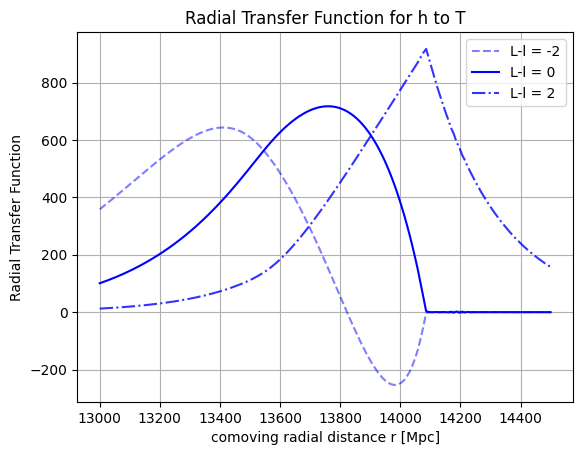

In [27]:
# tensor to T
delta_h_T1 = red_bisp[0, :, 46, 0, 0]
delta_h_T2 = red_bisp[2, :, 46, 0, 0]
delta_h_T3 = red_bisp[4, :, 46, 0, 0]

plt.plot(radii, radii**2*delta_h_T1, label=f'L-l = {-2}', color='b', alpha=0.5, linestyle='--')  
plt.plot(radii, radii**2*delta_h_T2, label=f'L-l = {0}', color='b', alpha=1, linestyle='-')  
plt.plot(radii, radii**2*delta_h_T3, label=f'L-l = {2}', color='b', alpha=0.8, linestyle='-.')  
plt.xlabel("comoving radial distance r [Mpc]")  # x label
plt.ylabel("Radial Transfer Function")  # y label
plt.title(f"Radial Transfer Function for h to T")  # title
plt.legend() 
plt.grid(True)  
plt.show()

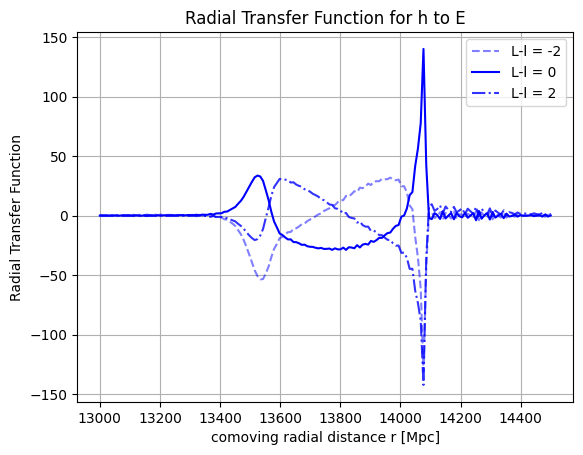

In [28]:
# tensor to E
delta_h_E1 = red_bisp[0, :, 46, 1, 0]
delta_h_E2 = red_bisp[2, :, 46, 1, 0]
delta_h_E3 = red_bisp[4, :, 46, 1, 0]

plt.plot(radii, radii**2*delta_h_E1, label=f'L-l = {-2}', color='b', alpha=0.5, linestyle='--')  
plt.plot(radii, radii**2*delta_h_E2, label=f'L-l = {0}', color='b', alpha=1, linestyle='-')  
plt.plot(radii, radii**2*delta_h_E3, label=f'L-l = {2}', color='b', alpha=0.8, linestyle='-.')  
plt.xlabel("comoving radial distance r [Mpc]")  # x label
plt.ylabel("Radial Transfer Function")  # y label
plt.title(f"Radial Transfer Function for h to E")  # title
plt.legend() 
plt.grid(True)  
plt.show()

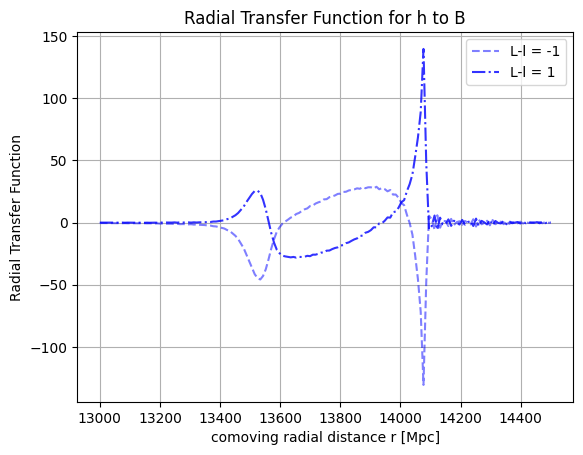

In [29]:
# tensor to B
delta_h_B1 = red_bisp[1, :, 46, 2, 0]
delta_h_B2 = red_bisp[3, :, 46, 2, 0]

plt.plot(radii, radii**2*delta_h_B1, label=f'L-l = {-1}', color='b', alpha=0.5, linestyle='--')  
plt.plot(radii, radii**2*delta_h_B2, label=f'L-l = {1}', color='b', alpha=0.8, linestyle='-.')  
plt.xlabel("comoving radial distance r [Mpc]")  # x label
plt.ylabel("Radial Transfer Function")  # y label
plt.title(f"Radial Transfer Function for h to B")  # title
plt.legend() 
plt.grid(True)  
plt.show()